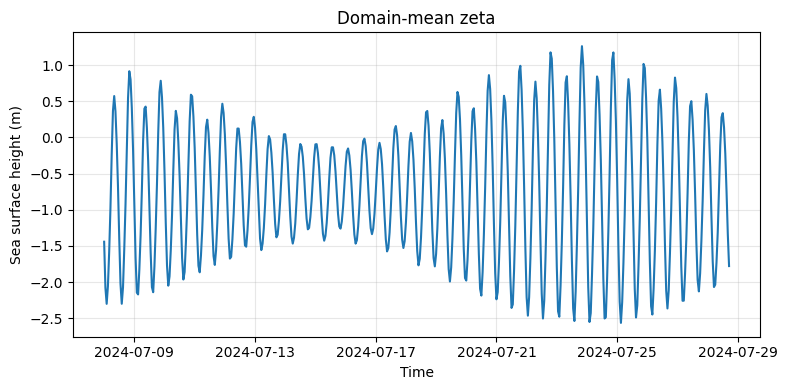

In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
x=xr.open_mfdataset('/home/x-uheede/S/Iceland3_MARBL_2024/Iceland3_MARBL_2024_his.2024??????????.nc', combine='nested', concat_dim=["time"])
x = x.assign_coords(
    ocean_time=pd.to_datetime("2000-01-01") + pd.to_timedelta(x.ocean_time, unit="s")
)
zeta = x["zeta"]

# --------------------------------
# Mask zero values
# --------------------------------
zeta_nonzero = zeta.where(zeta != 0)

# --------------------------------
# Domain mean of non-zero cells
# --------------------------------
zeta_mean = zeta_nonzero.mean(
    dim=["eta_rho", "xi_rho"],
    skipna=True
)
plt.figure(figsize=(8,4))
plt.plot(x['ocean_time'], zeta_mean)
plt.ylabel("Sea surface height (m)")
plt.xlabel("Time")
plt.title("Domain-mean zeta")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
a=xr.open_mfdataset('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202407.nc')
a



/tmp/ipykernel_1284361/153668229.py:1: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  a=xr.open_mfdataset('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202407.nc')


<xarray.Dataset> Size: 1GB
Dimensions:   (time: 744, eta_rho: 194, xi_rho: 322)
Coordinates:
    abs_time  (time) datetime64[ns] 6kB dask.array<chunksize=(512,), meta=np.ndarray>
  * time      (time) timedelta64[ns] 6kB 8948 days 00:00:00 ... 8978 days 23:...
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    uwnd      (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    vwnd      (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    swrad     (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    lwrad     (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    Tair      (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    rain      (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
    qair      (time, eta_rho, xi_rho) float32 186MB dask.array<chunksize=(1, 194, 322), meta=np.ndarray>
Attributes:
    title:                 ROMS surface forcing file created by ROMS-Tools
    roms_tools_version:    3.5.0
    start_time:            2023-12-01 00:00:00
    end_time:              2024-12-31 00:00:00
    source:                ERA5
    correct_radiation:     True
    wind_dropoff:          False
    use_coarse_grid:       True
    model_reference_date:  2000-01-01 00:00:00
    type:                  physics

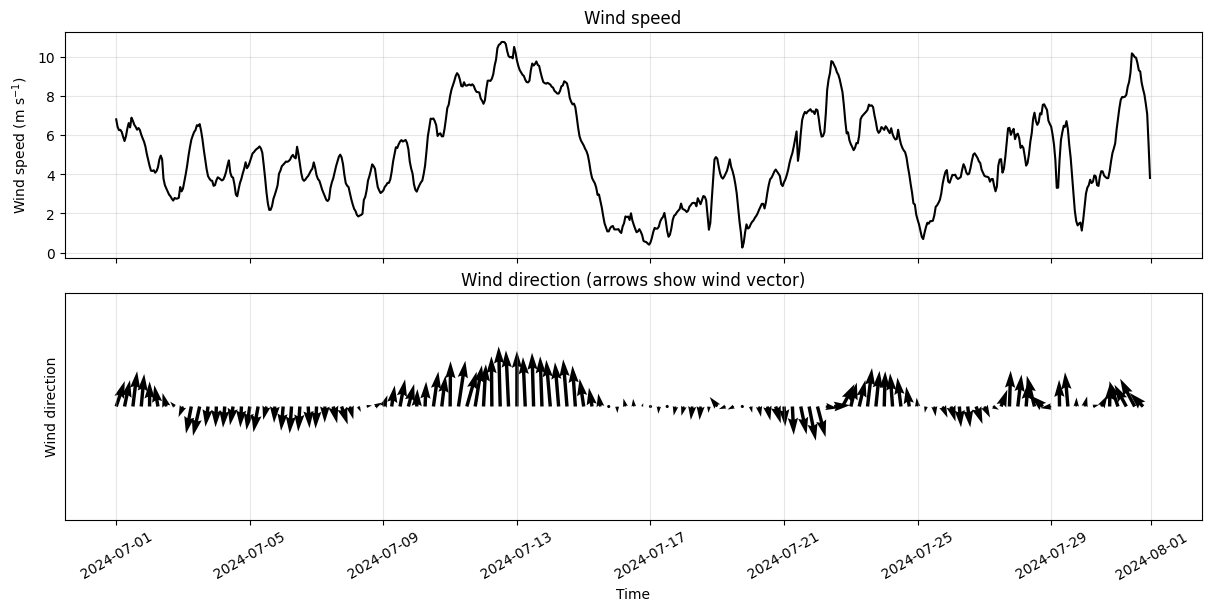

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------
# Domain mean wind
# --------------------------------
u = a["uwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
v = a["vwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()

time = a["abs_time"]

# --------------------------------
# Wind speed
# --------------------------------
speed = np.sqrt(u**2 + v**2)

# --------------------------------
# Plot
# --------------------------------
fig, axs = plt.subplots(
    2, 1,
    figsize=(12,6),
    sharex=True,
    constrained_layout=True
)

# ---- Wind speed
axs[0].plot(time, speed, color="k")
axs[0].set_ylabel("Wind speed (m s$^{-1}$)")
axs[0].set_title("Wind speed")
axs[0].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6  # controls arrow density

axs[1].quiver(
    time[::step],
    np.zeros_like(time[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[1].set_ylim(-1, 1)
axs[1].set_yticks([])
axs[1].set_ylabel("Wind direction")
axs[1].set_xlabel("Time")
axs[1].set_title("Wind direction (arrows show wind vector)")
axs[1].grid(alpha=0.3)

plt.xticks(rotation=30)
plt.show()

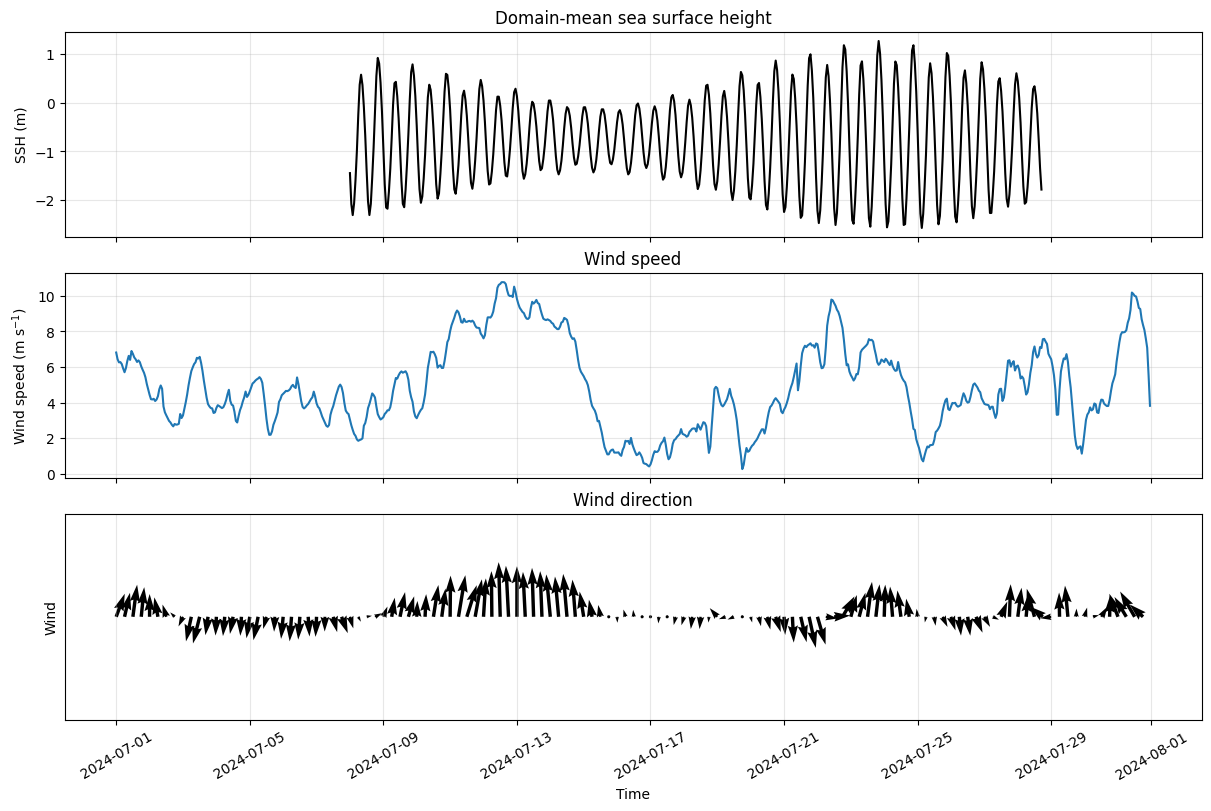

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# --------------------------------
# Wind (domain mean)
# --------------------------------
u = a["uwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
v = a["vwnd"].mean(dim=["eta_rho", "xi_rho"]).compute()
time_wind = a["abs_time"]

speed = np.sqrt(u**2 + v**2)

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(12,8),
    sharex=True,
    constrained_layout=True
)

# ---- Zeta
axs[0].plot(x["ocean_time"], zeta_mean, color="k")
axs[0].set_ylabel("SSH (m)")
axs[0].set_title("Domain-mean sea surface height")
axs[0].grid(alpha=0.3)

# ---- Wind speed
axs[1].plot(time_wind, speed, color="tab:blue")
axs[1].set_ylabel("Wind speed (m s$^{-1}$)")
axs[1].set_title("Wind speed")
axs[1].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6

axs[2].quiver(
    time_wind[::step],
    np.zeros_like(time_wind[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[2].set_ylim(-1,1)
axs[2].set_yticks([])
axs[2].set_ylabel("Wind")
axs[2].set_xlabel("Time")
axs[2].set_title("Wind direction")
axs[2].grid(alpha=0.3)

plt.xticks(rotation=30)

plt.show()

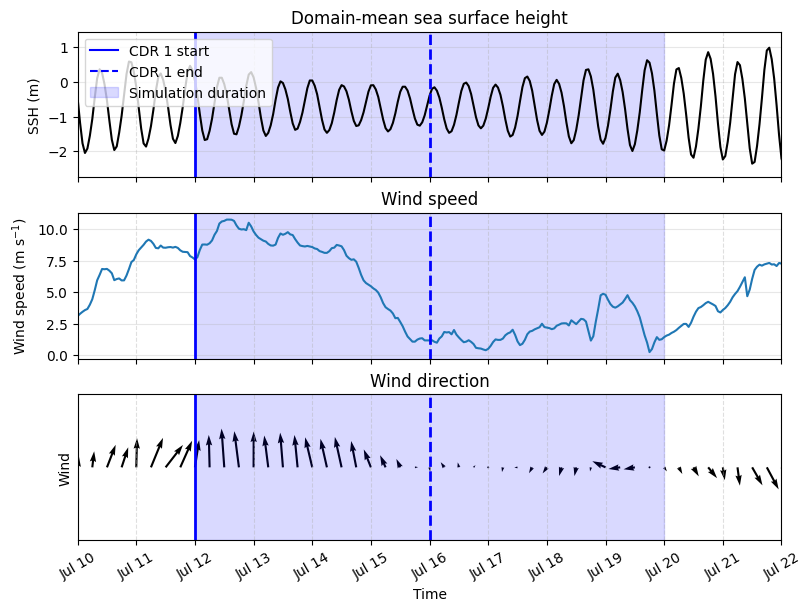

In [8]:
import matplotlib.dates as mdates

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(8,6),
    sharex=True,
    constrained_layout=True
)

# ---- Zeta
axs[0].plot(x["ocean_time"], zeta_mean, color="k")
axs[0].set_ylabel("SSH (m)")
axs[0].set_title("Domain-mean sea surface height")
axs[0].grid(alpha=0.3)

# ---- Wind speed
axs[1].plot(time_wind, speed, color="tab:blue")
axs[1].set_ylabel("Wind speed (m s$^{-1}$)")
axs[1].set_title("Wind speed")
axs[1].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6
axs[2].quiver(
    time_wind[::step],
    np.zeros_like(time_wind[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[2].set_ylim(-1,1)
axs[2].set_yticks([])
axs[2].set_ylabel("Wind")
axs[2].set_xlabel("Time")
axs[2].set_title("Wind direction")
axs[2].grid(alpha=0.3)

# --------------------------------
# Daily grid lines
# --------------------------------
day_locator = mdates.DayLocator()
day_fmt = mdates.DateFormatter("%b %d")

for ax in axs:
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_fmt)
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=30)

# --------------------------------
# Limit x-axis to July 10–20
# --------------------------------
x_start = np.datetime64("2024-07-10")
x_end   = np.datetime64("2024-07-22")

for ax in axs:
    ax.set_xlim(x_start, x_end)
# --------------------------------
# CDR simulation markers
# --------------------------------
cdr_start = np.datetime64("2024-07-12")
cdr_end   = np.datetime64("2024-07-16")
sim_end   = np.datetime64("2024-07-20")

for ax in axs:
    ax.axvline(cdr_start, color="blue", linestyle="-", linewidth=2)
    ax.axvline(cdr_end, color="blue", linestyle="--", linewidth=2)
    ax.axvspan(cdr_start, sim_end, color="blue", alpha=0.15)

# ---- Labels on top panel
ymax = axs[0].get_ylim()[1]

# ---- Legend
axs[0].plot([], [], color="blue", linestyle="-", label="CDR 1 start")
axs[0].plot([], [], color="blue", linestyle="--", label="CDR 1 end")
axs[0].fill_between([], [], [], color="blue", alpha=0.15, label="Simulation duration")

axs[0].legend()


In [14]:
from scipy.signal import find_peaks

# --------------------------------
# Simulation window
# --------------------------------
cdr_start = np.datetime64("2024-07-12")
cdr_end   = np.datetime64("2024-07-16")
sim_end   = np.datetime64("2024-07-20")

# --------------------------------
# Restrict SSH
# --------------------------------
zeta_time = pd.to_datetime(x["ocean_time"].values)

zeta_mask = (zeta_time >= cdr_start) & (zeta_time <= sim_end)

zeta_sim = zeta_mean.values[zeta_mask]
zeta_time_sim = zeta_time[zeta_mask]

# --------------------------------
# Restrict wind
# --------------------------------
time_wind_pd = pd.to_datetime(time_wind.values)

wind_mask = (time_wind_pd >= cdr_start) & (time_wind_pd <= sim_end)

speed_sim = speed.values[wind_mask]
u_sim = u.values[wind_mask]
v_sim = v.values[wind_mask]

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)

# --------------------------------
# Wind direction (meteorological degrees)
# --------------------------------
wind_dir = (270 - np.degrees(np.arctan2(v_sim, u_sim))) % 360

# --------------------------------
# Mode wind direction
# --------------------------------
bin_width = 10  # degrees
bins = np.arange(0, 360 + bin_width, bin_width)

hist, edges = np.histogram(wind_dir, bins=bins)

mode_bin_index = np.argmax(hist)
mode_wind_dir = (edges[mode_bin_index] + edges[mode_bin_index + 1]) / 2

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)
# --------------------------------
# Tidal range
# --------------------------------
peaks, _ = find_peaks(zeta_sim)
troughs, _ = find_peaks(-zeta_sim)

extrema = np.sort(np.concatenate([peaks, troughs]))

tidal_ranges = []
tidal_times = []

for i in range(len(extrema) - 1):
    
    idx1 = extrema[i]
    idx2 = extrema[i+1]
    
    range_val = abs(zeta_sim[idx2] - zeta_sim[idx1])
    
    tidal_ranges.append(range_val)
    tidal_times.append((zeta_time_sim[idx1], zeta_time_sim[idx2]))

tidal_ranges = np.array(tidal_ranges)

min_range = tidal_ranges.min()
max_range = tidal_ranges.max()

min_idx = tidal_ranges.argmin()
max_idx = tidal_ranges.argmax()

# --------------------------------
# Print results
# --------------------------------
print("\n--------------------------------")
print("Simulation duration statistics")
print("--------------------------------")

print(f"Average wind speed: {avg_wind_speed:.2f} m/s")
print(f"Most frequent wind direction: {mode_wind_dir:.0f}°")

print("\nMinimum tidal range:")
print(f"{min_range:.2f} m")
print(f"{tidal_times[min_idx][0]} → {tidal_times[min_idx][1]}")

print("\nMaximum tidal range:")
print(f"{max_range:.2f} m")
print(f"{tidal_times[max_idx][0]} → {tidal_times[max_idx][1]}")
print("--------------------------------")


--------------------------------
Simulation duration statistics
--------------------------------
Average wind speed: 4.71 m/s
Most frequent wind direction: 175°

Minimum tidal range:
1.11 m
2024-07-15 20:00:00 → 2024-07-16 02:00:00

Maximum tidal range:
2.62 m
2024-07-19 11:00:00 → 2024-07-19 17:00:00
--------------------------------


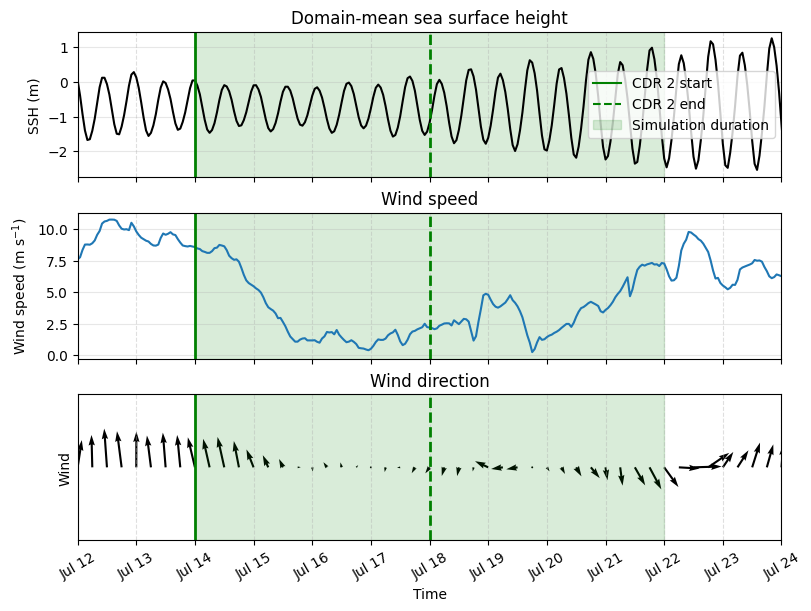

In [15]:
import matplotlib.dates as mdates

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(8,6),
    sharex=True,
    constrained_layout=True
)

# ---- Zeta
axs[0].plot(x["ocean_time"], zeta_mean, color="k")
axs[0].set_ylabel("SSH (m)")
axs[0].set_title("Domain-mean sea surface height")
axs[0].grid(alpha=0.3)

# ---- Wind speed
axs[1].plot(time_wind, speed, color="tab:blue")
axs[1].set_ylabel("Wind speed (m s$^{-1}$)")
axs[1].set_title("Wind speed")
axs[1].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6
axs[2].quiver(
    time_wind[::step],
    np.zeros_like(time_wind[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[2].set_ylim(-1,1)
axs[2].set_yticks([])
axs[2].set_ylabel("Wind")
axs[2].set_xlabel("Time")
axs[2].set_title("Wind direction")
axs[2].grid(alpha=0.3)

# --------------------------------
# Daily grid lines
# --------------------------------
day_locator = mdates.DayLocator()
day_fmt = mdates.DateFormatter("%b %d")

for ax in axs:
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_fmt)
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=30)

# --------------------------------
# Limit x-axis to July 10–20
# --------------------------------
x_start = np.datetime64("2024-07-12")
x_end   = np.datetime64("2024-07-24")

for ax in axs:
    ax.set_xlim(x_start, x_end)
# --------------------------------
# CDR simulation markers
# --------------------------------
cdr_start = np.datetime64("2024-07-14")
cdr_end   = np.datetime64("2024-07-18")
sim_end   = np.datetime64("2024-07-22")

for ax in axs:
    ax.axvline(cdr_start, color="green", linestyle="-", linewidth=2)
    ax.axvline(cdr_end, color="green", linestyle="--", linewidth=2)
    ax.axvspan(cdr_start, sim_end, color="green", alpha=0.15)

# ---- Labels on top panel
ymax = axs[0].get_ylim()[1]

# ---- Legend
axs[0].plot([], [], color="green", linestyle="-", label="CDR 2 start")
axs[0].plot([], [], color="green", linestyle="--", label="CDR 2 end")
axs[0].fill_between([], [], [], color="green", alpha=0.15, label="Simulation duration")

axs[0].legend()


In [16]:
from scipy.signal import find_peaks

# --------------------------------
# Simulation window
# --------------------------------
cdr_start = np.datetime64("2024-07-14")
cdr_end   = np.datetime64("2024-07-18")
sim_end   = np.datetime64("2024-07-22")

# --------------------------------
# Restrict SSH
# --------------------------------
zeta_time = pd.to_datetime(x["ocean_time"].values)

zeta_mask = (zeta_time >= cdr_start) & (zeta_time <= sim_end)

zeta_sim = zeta_mean.values[zeta_mask]
zeta_time_sim = zeta_time[zeta_mask]

# --------------------------------
# Restrict wind
# --------------------------------
time_wind_pd = pd.to_datetime(time_wind.values)

wind_mask = (time_wind_pd >= cdr_start) & (time_wind_pd <= sim_end)

speed_sim = speed.values[wind_mask]
u_sim = u.values[wind_mask]
v_sim = v.values[wind_mask]

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)

# --------------------------------
# Wind direction (meteorological degrees)
# --------------------------------
wind_dir = (270 - np.degrees(np.arctan2(v_sim, u_sim))) % 360

# --------------------------------
# Mode wind direction
# --------------------------------
bin_width = 10  # degrees
bins = np.arange(0, 360 + bin_width, bin_width)

hist, edges = np.histogram(wind_dir, bins=bins)

mode_bin_index = np.argmax(hist)
mode_wind_dir = (edges[mode_bin_index] + edges[mode_bin_index + 1]) / 2

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)
# --------------------------------
# Tidal range
# --------------------------------
peaks, _ = find_peaks(zeta_sim)
troughs, _ = find_peaks(-zeta_sim)

extrema = np.sort(np.concatenate([peaks, troughs]))

tidal_ranges = []
tidal_times = []

for i in range(len(extrema) - 1):
    
    idx1 = extrema[i]
    idx2 = extrema[i+1]
    
    range_val = abs(zeta_sim[idx2] - zeta_sim[idx1])
    
    tidal_ranges.append(range_val)
    tidal_times.append((zeta_time_sim[idx1], zeta_time_sim[idx2]))

tidal_ranges = np.array(tidal_ranges)

min_range = tidal_ranges.min()
max_range = tidal_ranges.max()

min_idx = tidal_ranges.argmin()
max_idx = tidal_ranges.argmax()

# --------------------------------
# Print results
# --------------------------------
print("\n--------------------------------")
print("Simulation duration statistics")
print("--------------------------------")

print(f"Average wind speed: {avg_wind_speed:.2f} m/s")
print(f"Most frequent wind direction: {mode_wind_dir:.0f}°")

print("\nMinimum tidal range:")
print(f"{min_range:.2f} m")
print(f"{tidal_times[min_idx][0]} → {tidal_times[min_idx][1]}")

print("\nMaximum tidal range:")
print(f"{max_range:.2f} m")
print(f"{tidal_times[max_idx][0]} → {tidal_times[max_idx][1]}")
print("--------------------------------")


--------------------------------
Simulation duration statistics
--------------------------------
Average wind speed: 3.50 m/s
Most frequent wind direction: 165°

Minimum tidal range:
1.11 m
2024-07-15 20:00:00 → 2024-07-16 02:00:00

Maximum tidal range:
3.35 m
2024-07-21 12:00:00 → 2024-07-21 19:00:00
--------------------------------


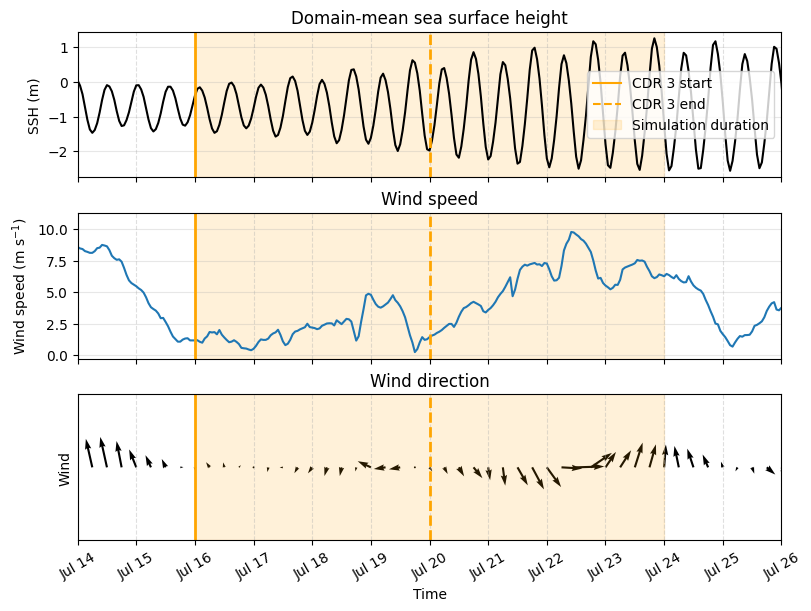

In [17]:
import matplotlib.dates as mdates

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(8,6),
    sharex=True,
    constrained_layout=True
)

# ---- Zeta
axs[0].plot(x["ocean_time"], zeta_mean, color="k")
axs[0].set_ylabel("SSH (m)")
axs[0].set_title("Domain-mean sea surface height")
axs[0].grid(alpha=0.3)

# ---- Wind speed
axs[1].plot(time_wind, speed, color="tab:blue")
axs[1].set_ylabel("Wind speed (m s$^{-1}$)")
axs[1].set_title("Wind speed")
axs[1].grid(alpha=0.3)

# ---- Wind direction arrows
step = 6
axs[2].quiver(
    time_wind[::step],
    np.zeros_like(time_wind[::step]),
    u[::step],
    v[::step],
    angles="xy",
    scale_units="xy",
    scale=20,
    width=0.003
)

axs[2].set_ylim(-1,1)
axs[2].set_yticks([])
axs[2].set_ylabel("Wind")
axs[2].set_xlabel("Time")
axs[2].set_title("Wind direction")
axs[2].grid(alpha=0.3)

# --------------------------------
# Daily grid lines
# --------------------------------
day_locator = mdates.DayLocator()
day_fmt = mdates.DateFormatter("%b %d")

for ax in axs:
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_fmt)
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.xticks(rotation=30)

# --------------------------------
# Limit x-axis to July 10–20
# --------------------------------
x_start = np.datetime64("2024-07-14")
x_end   = np.datetime64("2024-07-26")

for ax in axs:
    ax.set_xlim(x_start, x_end)
# --------------------------------
# CDR simulation markers
# --------------------------------
cdr_start = np.datetime64("2024-07-16")
cdr_end   = np.datetime64("2024-07-20")
sim_end   = np.datetime64("2024-07-24")

for ax in axs:
    ax.axvline(cdr_start, color="orange", linestyle="-", linewidth=2)
    ax.axvline(cdr_end, color="orange", linestyle="--", linewidth=2)
    ax.axvspan(cdr_start, sim_end, color="orange", alpha=0.15)

# ---- Labels on top panel
ymax = axs[0].get_ylim()[1]

# ---- Legend
axs[0].plot([], [], color="orange", linestyle="-", label="CDR 3 start")
axs[0].plot([], [], color="orange", linestyle="--", label="CDR 3 end")
axs[0].fill_between([], [], [], color="orange", alpha=0.15, label="Simulation duration")

axs[0].legend()


In [18]:
from scipy.signal import find_peaks

# --------------------------------
# Simulation window
# --------------------------------
cdr_start = np.datetime64("2024-07-16")
cdr_end   = np.datetime64("2024-07-20")
sim_end   = np.datetime64("2024-07-24")

# --------------------------------
# Restrict SSH
# --------------------------------
zeta_time = pd.to_datetime(x["ocean_time"].values)

zeta_mask = (zeta_time >= cdr_start) & (zeta_time <= sim_end)

zeta_sim = zeta_mean.values[zeta_mask]
zeta_time_sim = zeta_time[zeta_mask]

# --------------------------------
# Restrict wind
# --------------------------------
time_wind_pd = pd.to_datetime(time_wind.values)

wind_mask = (time_wind_pd >= cdr_start) & (time_wind_pd <= sim_end)

speed_sim = speed.values[wind_mask]
u_sim = u.values[wind_mask]
v_sim = v.values[wind_mask]

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)

# --------------------------------
# Wind direction (meteorological degrees)
# --------------------------------
wind_dir = (270 - np.degrees(np.arctan2(v_sim, u_sim))) % 360

# --------------------------------
# Mode wind direction
# --------------------------------
bin_width = 10  # degrees
bins = np.arange(0, 360 + bin_width, bin_width)

hist, edges = np.histogram(wind_dir, bins=bins)

mode_bin_index = np.argmax(hist)
mode_wind_dir = (edges[mode_bin_index] + edges[mode_bin_index + 1]) / 2

# --------------------------------
# Average wind speed
# --------------------------------
avg_wind_speed = np.mean(speed_sim)
# --------------------------------
# Tidal range
# --------------------------------
peaks, _ = find_peaks(zeta_sim)
troughs, _ = find_peaks(-zeta_sim)

extrema = np.sort(np.concatenate([peaks, troughs]))

tidal_ranges = []
tidal_times = []

for i in range(len(extrema) - 1):
    
    idx1 = extrema[i]
    idx2 = extrema[i+1]
    
    range_val = abs(zeta_sim[idx2] - zeta_sim[idx1])
    
    tidal_ranges.append(range_val)
    tidal_times.append((zeta_time_sim[idx1], zeta_time_sim[idx2]))

tidal_ranges = np.array(tidal_ranges)

min_range = tidal_ranges.min()
max_range = tidal_ranges.max()

min_idx = tidal_ranges.argmin()
max_idx = tidal_ranges.argmax()

# --------------------------------
# Print results
# --------------------------------
print("\n--------------------------------")
print("Simulation duration statistics")
print("--------------------------------")

print(f"Average wind speed: {avg_wind_speed:.2f} m/s")
print(f"Most frequent wind direction: {mode_wind_dir:.0f}°")

print("\nMinimum tidal range:")
print(f"{min_range:.2f} m")
print(f"{tidal_times[min_idx][0]} → {tidal_times[min_idx][1]}")

print("\nMaximum tidal range:")
print(f"{max_range:.2f} m")
print(f"{tidal_times[max_idx][0]} → {tidal_times[max_idx][1]}")
print("--------------------------------")


--------------------------------
Simulation duration statistics
--------------------------------
Average wind speed: 3.95 m/s
Most frequent wind direction: 325°

Minimum tidal range:
1.26 m
2024-07-16 21:00:00 → 2024-07-17 03:00:00

Maximum tidal range:
3.80 m
2024-07-23 14:00:00 → 2024-07-23 20:00:00
--------------------------------


July 12th: Strong wind from south, medium tides

July 14th: strong winds, low tides

July 16th: Low tides, low wind

July 21st: High tides, strong winds from north

July 24th: High tides, strong winds from south

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
x=xr.open_mfdataset('/home/x-uheede/S/Iceland3_MARBL_2024/Iceland3_MARBL_2024_his.2024??????????.nc', combine='nested', concat_dim=["time"])
x = x.assign_coords(
    ocean_time=pd.to_datetime("2000-01-01") + pd.to_timedelta(x.ocean_time, unit="s")
)
zeta = x["zeta"]

# --------------------------------
# Mask zero values
# --------------------------------
zeta_nonzero = zeta.where(zeta != 0)

# --------------------------------
# Domain mean of non-zero cells
# --------------------------------
zeta_mean = zeta_nonzero.mean(
    dim=["eta_rho", "xi_rho"],
    skipna=True
)
plt.figure(figsize=(8,4))
plt.plot(x['ocean_time'], zeta_mean)
plt.ylabel("Sea surface height (m)")
plt.xlabel("Time")
plt.title("Domain-mean zeta")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()